# SABR Model Tutorial

This tutorial covers the SABR (Stochastic Alpha Beta Rho) model, the industry standard for volatility smile modeling in interest rates and FX markets.

## Overview

The SABR model is widely used because:
- **Analytic formula**: Fast implied vol computation (Hagan approximation)
- **Smile dynamics**: Captures how smile moves with forward
- **Industry standard**: Used by most rates/FX desks
- **Flexible backbone**: Different β for different markets

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
## Part 1: SABR Model Specification

### Model Dynamics

Under the forward measure, SABR specifies:

$$dF_t = \sigma_t F_t^\beta dW_t^F$$
$$d\sigma_t = \nu \sigma_t dW_t^\sigma$$
$$dW_t^F dW_t^\sigma = \rho \, dt$$

**Parameters:**
- α (alpha): Initial volatility level
- β (beta): CEV exponent (backbone)
- ρ (rho): Spot-vol correlation (creates skew)
- ν (nu): Vol-of-vol (creates smile curvature)

In [2]:
from src.calibration.volatility_surface.sabr import (
    SabrParameters,
    sabr_implied_vol,
    sabr_implied_vol_vec,
    calibrate_sabr_to_smile,
)

# Define SABR parameters
params = SabrParameters(
    alpha=0.3,    # Initial volatility (30%)
    beta=1.0,     # Log-normal backbone
    rho=-0.5,     # Negative correlation (creates negative skew)
    nu=0.4,       # Vol-of-vol (creates curvature)
)

print("SABR Parameters:")
print(f"  α (alpha): {params.alpha:.2f}")
print(f"  β (beta): {params.beta:.1f}")
print(f"  ρ (rho): {params.rho:.2f}")
print(f"  ν (nu): {params.nu:.2f}")

SABR Parameters:
  α (alpha): 0.30
  β (beta): 1.0
  ρ (rho): -0.50
  ν (nu): 0.40


### β (Beta) Conventions

| β Value | Name | Use Case |
|---------|------|----------|
| β = 0 | Normal SABR | Negative rates, swaptions |
| β = 0.5 | CIR-like | Intermediate |
| β = 1 | Log-normal SABR | FX, caps (most common) |

---
## Part 2: Hagan Implied Volatility Formula

The SABR model's power comes from the analytic approximation for implied volatility.

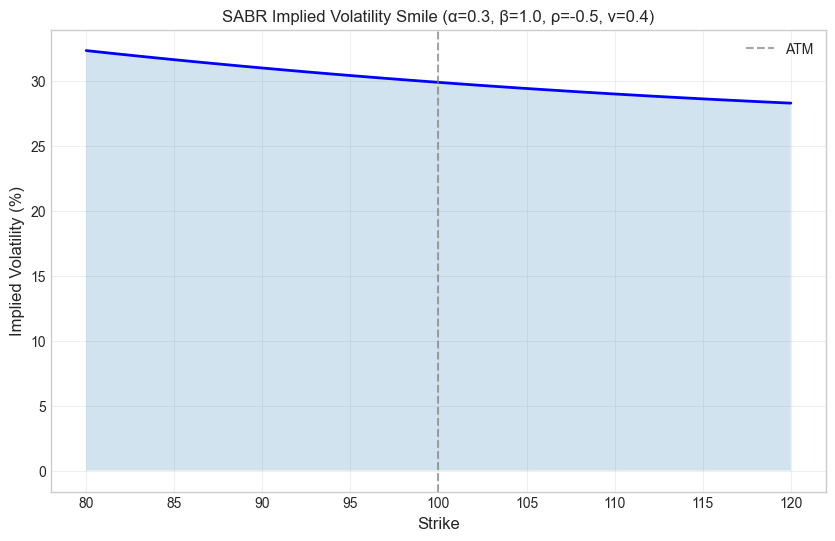

ATM implied vol: 29.90%


In [3]:
# Compute implied vol across strikes
F = 100.0  # Forward price
T = 0.5    # 6-month expiry
strikes = np.linspace(80, 120, 41)

impl_vols = sabr_implied_vol_vec(
    forward=F,
    strikes=strikes,
    expiry=T,
    params=params,
)

# Plot the smile
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(strikes, impl_vols * 100, 'b-', linewidth=2)
ax.axvline(x=F, color='gray', linestyle='--', alpha=0.7, label='ATM')
ax.fill_between(strikes, impl_vols * 100, alpha=0.2)

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title(f'SABR Implied Volatility Smile (α={params.alpha}, β={params.beta}, ρ={params.rho}, ν={params.nu})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# ATM vol
atm_vol = sabr_implied_vol(forward=F, strike=F, expiry=T, params=params)
print(f"ATM implied vol: {atm_vol:.2%}")

### Effect of ρ (Correlation) - Creates Skew

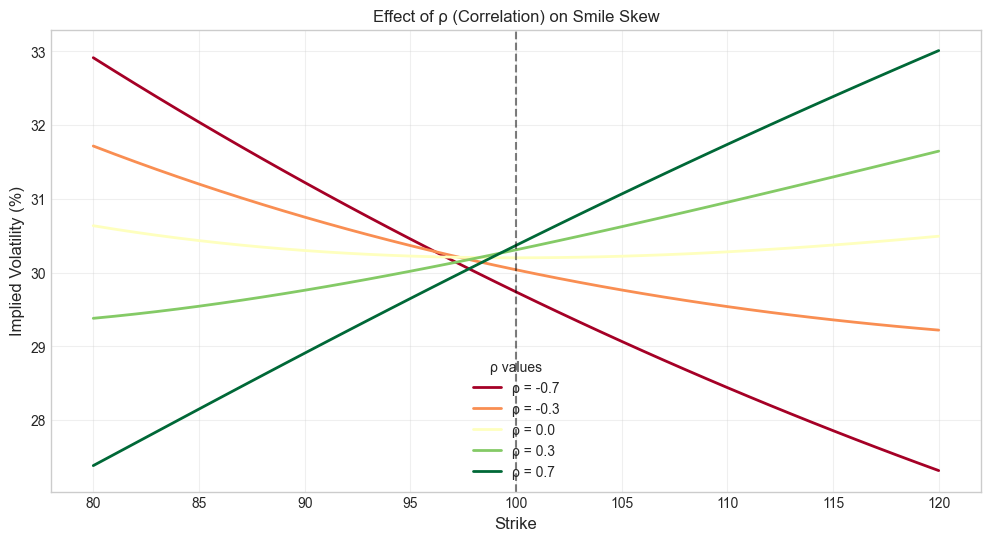

Key insight: Negative ρ creates negative skew (higher OTM put vols)
This is typical for equities and many FX pairs.


In [4]:
rho_values = [-0.7, -0.3, 0.0, 0.3, 0.7]
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(rho_values)))

fig, ax = plt.subplots(figsize=(12, 6))

for rho, color in zip(rho_values, colors):
    p = SabrParameters(alpha=0.3, beta=1.0, rho=rho, nu=0.4)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, color=color, linewidth=2, label=f'ρ = {rho}')

ax.axvline(x=F, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Effect of ρ (Correlation) on Smile Skew', fontsize=12)
ax.legend(title='ρ values')
ax.grid(True, alpha=0.3)
plt.show()

print("Key insight: Negative ρ creates negative skew (higher OTM put vols)")
print("This is typical for equities and many FX pairs.")

### Effect of ν (Vol-of-Vol) - Creates Curvature

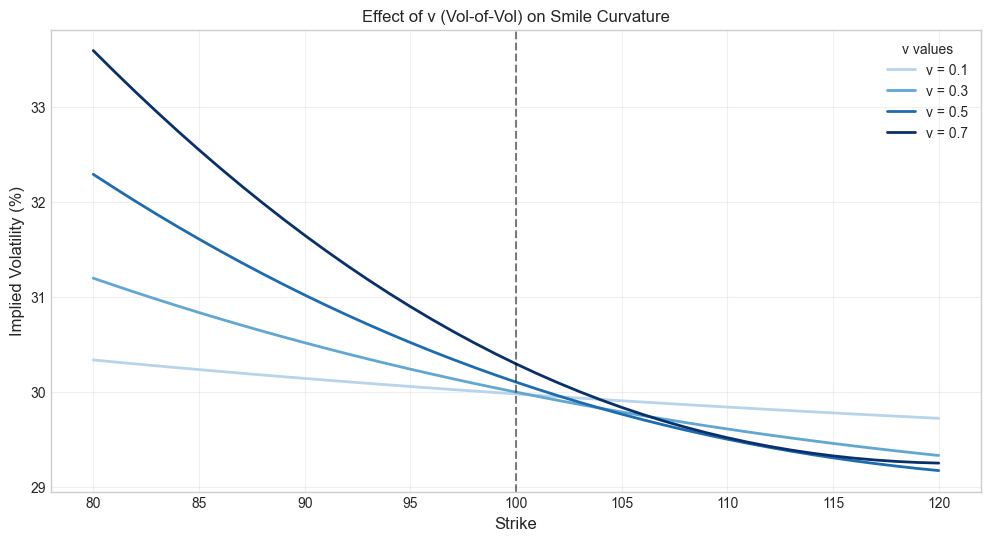

Key insight: Higher ν creates more smile curvature (kurtosis).


In [5]:
nu_values = [0.1, 0.3, 0.5, 0.7]
colors = plt.cm.Blues(np.linspace(0.3, 1, len(nu_values)))

fig, ax = plt.subplots(figsize=(12, 6))

for nu, color in zip(nu_values, colors):
    p = SabrParameters(alpha=0.3, beta=1.0, rho=-0.3, nu=nu)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, color=color, linewidth=2, label=f'ν = {nu}')

ax.axvline(x=F, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Effect of ν (Vol-of-Vol) on Smile Curvature', fontsize=12)
ax.legend(title='ν values')
ax.grid(True, alpha=0.3)
plt.show()

print("Key insight: Higher ν creates more smile curvature (kurtosis).")

### Effect of β (Backbone)

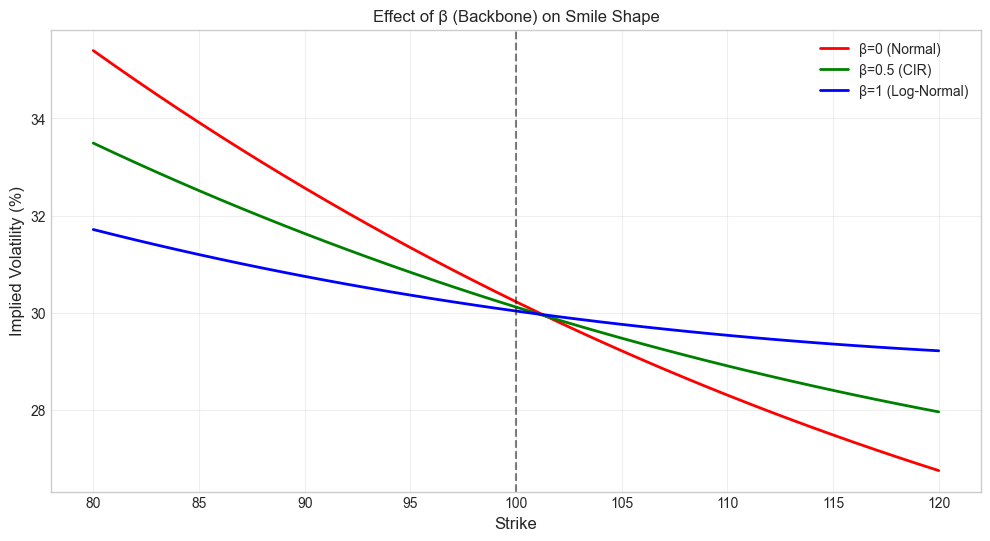

In [6]:
beta_values = [0.0, 0.5, 1.0]
labels = ['β=0 (Normal)', 'β=0.5 (CIR)', 'β=1 (Log-Normal)']
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots(figsize=(12, 6))

for beta, label, color in zip(beta_values, labels, colors):
    # Adjust alpha to get similar ATM vol for comparison
    if beta == 0:
        alpha = 0.3 * F  # Normal vol has different units
    elif beta == 0.5:
        alpha = 0.3 * np.sqrt(F)
    else:
        alpha = 0.3
    
    p = SabrParameters(alpha=alpha, beta=beta, rho=-0.3, nu=0.4)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, color=color, linewidth=2, label=label)

ax.axvline(x=F, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Effect of β (Backbone) on Smile Shape', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## Part 3: SABR Monte Carlo Simulation

For path-dependent products or when Hagan approximation breaks down, we use Monte Carlo.

In [7]:
from src.models.stochastic_volatility import SabrDynamics, SabrSimulation

# Create SABR dynamics
sabr_dynamics = SabrDynamics(params=params)

# Simulate paths
sabr_sim = sabr_dynamics.simulate(
    forward0=100.0,
    maturity=1.0,
    n_paths=10000,
    n_steps=252,
    scheme='log_euler',
    seed=42,
)

print(f"SABR Simulation:")
print(f"  Paths: {sabr_sim.n_paths}")
print(f"  Steps: {sabr_sim.n_steps}")
print(f"  Scheme: {sabr_sim.scheme}")
print(f"  Terminal forward mean: {sabr_sim.terminal_forwards.mean():.2f}")
print(f"  Terminal vol mean: {sabr_sim.terminal_vols.mean():.4f}")
print(f"  Initial vol (α): {params.alpha:.4f}")

SABR Simulation:
  Paths: 10000
  Steps: 252
  Scheme: log_euler
  Terminal forward mean: 100.11
  Terminal vol mean: 0.3002
  Initial vol (α): 0.3000


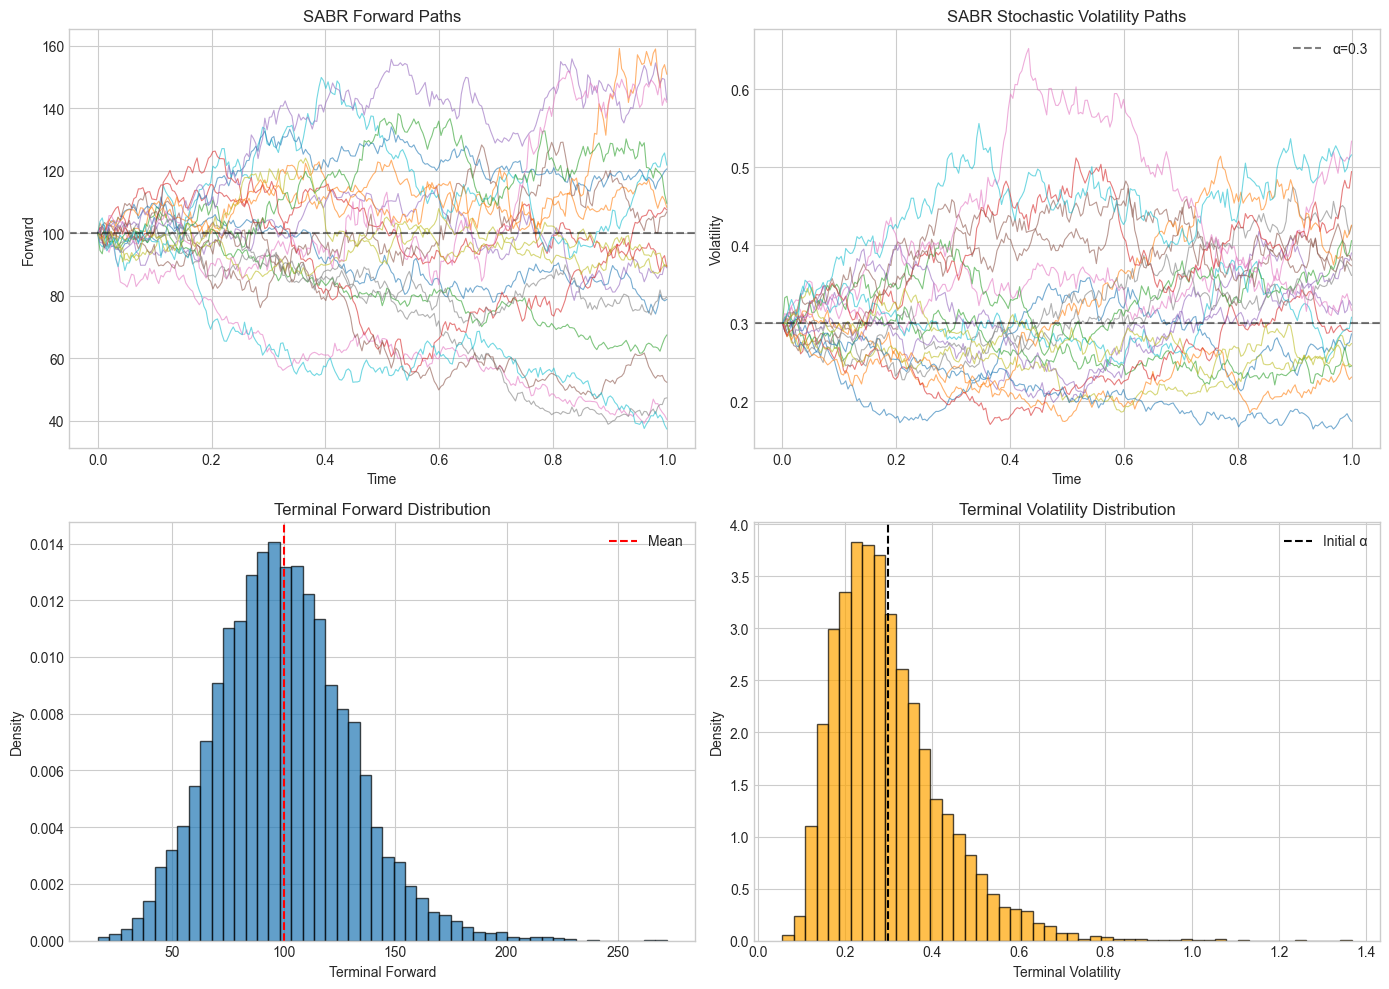

In [8]:
# Visualize SABR paths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Forward paths
ax1 = axes[0, 0]
for i in range(20):
    ax1.plot(sabr_sim.times, sabr_sim.forward_paths[i], alpha=0.6, linewidth=0.8)
ax1.axhline(y=100, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time')
ax1.set_ylabel('Forward')
ax1.set_title('SABR Forward Paths')

# Volatility paths
ax2 = axes[0, 1]
for i in range(20):
    ax2.plot(sabr_sim.times, sabr_sim.vol_paths[i], alpha=0.6, linewidth=0.8)
ax2.axhline(y=params.alpha, color='black', linestyle='--', alpha=0.5, label=f'α={params.alpha}')
ax2.set_xlabel('Time')
ax2.set_ylabel('Volatility')
ax2.set_title('SABR Stochastic Volatility Paths')
ax2.legend()

# Terminal forward distribution
ax3 = axes[1, 0]
ax3.hist(sabr_sim.terminal_forwards, bins=50, density=True, alpha=0.7, edgecolor='black')
ax3.axvline(x=sabr_sim.terminal_forwards.mean(), color='red', linestyle='--', label='Mean')
ax3.set_xlabel('Terminal Forward')
ax3.set_ylabel('Density')
ax3.set_title('Terminal Forward Distribution')
ax3.legend()

# Terminal vol distribution
ax4 = axes[1, 1]
ax4.hist(sabr_sim.terminal_vols, bins=50, density=True, alpha=0.7, edgecolor='black', color='orange')
ax4.axvline(x=params.alpha, color='black', linestyle='--', label=f'Initial α')
ax4.set_xlabel('Terminal Volatility')
ax4.set_ylabel('Density')
ax4.set_title('Terminal Volatility Distribution')
ax4.legend()

plt.tight_layout()
plt.show()

### MC vs Hagan Pricing Comparison

In [9]:
from src.models.stochastic_volatility.sabr import sabr_mc_call

# Black call formula
def black_call(F, K, T, sigma, df):
    d1 = (np.log(F/K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return df * (F * norm.cdf(d1) - K * norm.cdf(d2))

# Compare prices across strikes
F, T, df = 100.0, 0.5, 0.975
test_strikes = np.array([85, 90, 95, 100, 105, 110, 115])

print(f"{'Strike':>8} {'Hagan Vol':>12} {'Black Price':>12} {'MC Price':>12} {'Diff':>10}")
print("-" * 56)

for K in test_strikes:
    # Hagan implied vol
    hagan_vol = sabr_implied_vol(forward=F, strike=K, expiry=T, params=params)
    
    # Black price with Hagan vol
    hagan_price = black_call(F, K, T, hagan_vol, df)
    
    # MC price (direct SABR simulation)
    mc_price = sabr_mc_call(F, K, T, df, params, n_paths=100000, seed=42)
    
    diff_pct = (mc_price / hagan_price - 1) * 100 if hagan_price > 0.01 else 0
    
    print(f"{K:>8} {hagan_vol:>12.2%} {hagan_price:>12.4f} {mc_price:>12.4f} {diff_pct:>+9.2f}%")

print("\nNote: MC and Hagan should be close for ATM, may differ for deep OTM.")

  Strike    Hagan Vol  Black Price     MC Price       Diff
--------------------------------------------------------
      85       31.65%      17.3633      17.3501     -0.08%
      90       31.01%      13.8716      13.8547     -0.12%
      95       30.43%      10.8102      10.7922     -0.17%
     100       29.90%       8.2085       8.1933     -0.19%
     105       29.43%       6.0694       6.0635     -0.10%
     110       29.00%       4.3699       4.3714     +0.04%
     115       28.63%       3.0651       3.0776     +0.41%

Note: MC and Hagan should be close for ATM, may differ for deep OTM.


---
## Part 4: SABR Calibration

Calibrating SABR to market smile data.

In [10]:
# Generate synthetic market data (from a "true" SABR)
true_params = SabrParameters(alpha=0.25, beta=1.0, rho=-0.4, nu=0.35)

F = 100.0
T = 0.5
market_strikes = np.array([85, 90, 95, 100, 105, 110, 115])
market_vols = sabr_implied_vol_vec(forward=F, strikes=market_strikes, expiry=T, params=true_params)

# Add some noise to simulate market quotes
np.random.seed(42)
market_vols_noisy = market_vols + np.random.normal(0, 0.002, len(market_vols))

print("Market Quotes (simulated):")
print(f"{'Strike':>8} {'Vol':>12}")
for K, vol in zip(market_strikes, market_vols_noisy):
    print(f"{K:>8} {vol:>12.2%}")

Market Quotes (simulated):
  Strike          Vol
      85       26.37%
      90       25.76%
      95       25.49%
     100       25.29%
     105       24.61%
     110       24.33%
     115       24.46%


In [11]:
from src.calibration.volatility_surface.sabr import SabrConfig

# Calibrate SABR to market
config = SabrConfig(beta=1.0)  # Fix beta at 1 (log-normal)

calibrated_params = calibrate_sabr_to_smile(
    forward=F,
    strikes=market_strikes,
    market_vols=market_vols_noisy,
    expiry=T,
    config=config,
)

print("Calibration Results:")
print(f"{'Parameter':>10} {'True':>12} {'Calibrated':>12} {'Error':>10}")
print("-" * 46)
print(f"{'α':>10} {true_params.alpha:>12.4f} {calibrated_params.alpha:>12.4f} {abs(calibrated_params.alpha - true_params.alpha):>10.4f}")
print(f"{'β':>10} {true_params.beta:>12.4f} {calibrated_params.beta:>12.4f} {'(fixed)':>10}")
print(f"{'ρ':>10} {true_params.rho:>12.4f} {calibrated_params.rho:>12.4f} {abs(calibrated_params.rho - true_params.rho):>10.4f}")
print(f"{'ν':>10} {true_params.nu:>12.4f} {calibrated_params.nu:>12.4f} {abs(calibrated_params.nu - true_params.nu):>10.4f}")

Calibration Results:
 Parameter         True   Calibrated      Error
----------------------------------------------
         α       0.2500       0.2477     0.0023
         β       1.0000       1.0000    (fixed)
         ρ      -0.4000      -0.2324     0.1676
         ν       0.3500       0.5598     0.2098


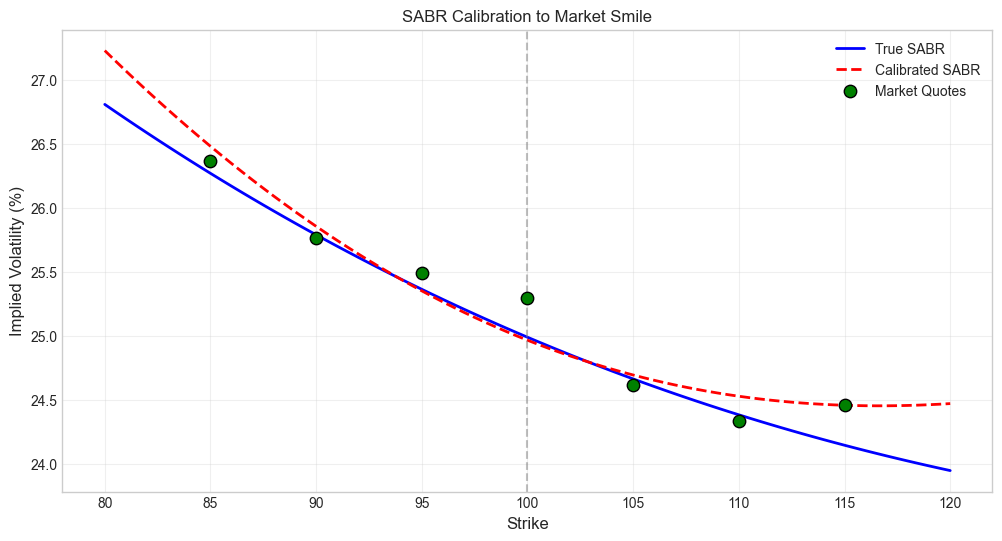

In [12]:
# Plot calibration fit
fine_strikes = np.linspace(80, 120, 81)
true_vols = sabr_implied_vol_vec(forward=F, strikes=fine_strikes, expiry=T, params=true_params)
calibrated_vols = sabr_implied_vol_vec(forward=F, strikes=fine_strikes, expiry=T, params=calibrated_params)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(fine_strikes, true_vols * 100, 'b-', linewidth=2, label='True SABR')
ax.plot(fine_strikes, calibrated_vols * 100, 'r--', linewidth=2, label='Calibrated SABR')
ax.scatter(market_strikes, market_vols_noisy * 100, s=80, c='green', marker='o', 
           zorder=5, label='Market Quotes', edgecolors='black')
ax.axvline(x=F, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('SABR Calibration to Market Smile', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## Part 5: Use Cases and Best Practices

### When to Use SABR

**Good for:**
- Interest rate swaptions and caps
- FX options (vanilla)
- Interpolating between market strikes
- Consistent smile dynamics

**Not ideal for:**
- Very long maturities (Hagan breaks down)
- Deep OTM strikes
- Path-dependent products (use MC)

### β Selection Guide

| Market | Typical β | Reason |
|--------|-----------|--------|
| FX | 1.0 | Log-normal behavior |
| EUR Swaptions | 0.0 - 0.5 | Negative rates possible |
| USD Swaptions | 0.5 - 1.0 | Positive rates |
| Caps/Floors | 1.0 | Log-normal LIBOR |

### Calibration Tips

1. **Always fix β** based on market convention
2. **Initialize α** from ATM vol
3. **Watch for arbitrage** in Hagan formula for extreme parameters
4. **Use weights** to prioritize ATM and near-money strikes

In [13]:
# Example: Term structure calibration
expiries = [0.25, 0.5, 1.0, 2.0]

print("Term Structure Calibration Example:")
print(f"{'Expiry':>8} {'α':>10} {'ρ':>10} {'ν':>10}")
print("-" * 40)

for T in expiries:
    # Generate synthetic market data for each expiry
    # In practice, you'd use actual market quotes
    true_p = SabrParameters(
        alpha=0.25 - 0.02 * T,  # Alpha tends to decrease with T
        beta=1.0,
        rho=-0.4 + 0.05 * T,    # Skew may flatten
        nu=0.35 - 0.03 * T,     # Smile curvature decreases
    )
    mkt_vols = sabr_implied_vol_vec(forward=F, strikes=market_strikes, expiry=T, params=true_p)
    
    # Calibrate
    cal_p = calibrate_sabr_to_smile(
        forward=F, strikes=market_strikes, market_vols=mkt_vols, expiry=T,
        config=SabrConfig(beta=1.0)
    )
    
    print(f"{T:>8.2f} {cal_p.alpha:>10.4f} {cal_p.rho:>10.4f} {cal_p.nu:>10.4f}")

Term Structure Calibration Example:
  Expiry          α          ρ          ν
----------------------------------------
    0.25     0.2447    -0.3491     0.3753
    0.50     0.2395    -0.3329     0.3714
    1.00     0.2293    -0.3078     0.3567
    2.00     0.2090    -0.2607     0.3237


---
## Summary

### Key Takeaways

1. **SABR Parameters**:
   - α: ATM vol level
   - β: Backbone (fix based on market)
   - ρ: Skew direction (negative = downside skew)
   - ν: Smile curvature

2. **Hagan Formula**:
   - Fast analytic approximation
   - Good for ATM and near-money
   - May fail for deep OTM or long maturities

3. **Monte Carlo**:
   - Use for path-dependent or when Hagan fails
   - Multiple discretization schemes available

4. **Calibration**:
   - Fix β, calibrate (α, ρ, ν)
   - Initialize from ATM vol
   - Check for arbitrage

### Related Tutorials

- [Jump and Lévy Models](jump_levy_models.ipynb) - Alternative smile models
- [Heston Stochastic Volatility](heston_pricing.ipynb) - Path-dependent exotics